In [1]:
import pandas as pd


df = pd.read_csv("dataset.csv")
df["explicit"] = df["explicit"].astype(int)
genres = df['track_genre']

df = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre'])

print(df.columns)
print(df.head())


Index(['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')
   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          73       230666         0         0.676  0.4610    1    -6.746   
1          55       149610         0         0.420  0.1660    1   -17.235   
2          57       210826         0         0.438  0.3590    0    -9.734   
3          71       201933         0         0.266  0.0596    0   -18.515   
4          82       198853         0         0.618  0.4430    2    -9.681   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     0       0.1430        0.0322          0.000001    0.3580    0.715   
1     1       0.0763        0.9240          0.000006    0.1010    0.267   
2     1       0.0557        0.2100          0.000000    0.1170    0.120  

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(X_scaled.mean(axis=0))
print(X_scaled.std(axis=0))


[-2.49313241e-17  2.19395652e-17  0.00000000e+00  4.06879209e-16
 -2.11417628e-16 -8.77582607e-17 -1.27648379e-16 -2.99175889e-17
  7.97802370e-18 -9.57362844e-17 -1.59560474e-17  1.13686838e-16
  1.59560474e-16 -4.98626481e-16 -3.90923161e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Wyjaśniona wariancja przez komponenty: [0.19986226 0.10309419]
Wartosci wlasne: [2.9979602  1.54642644]


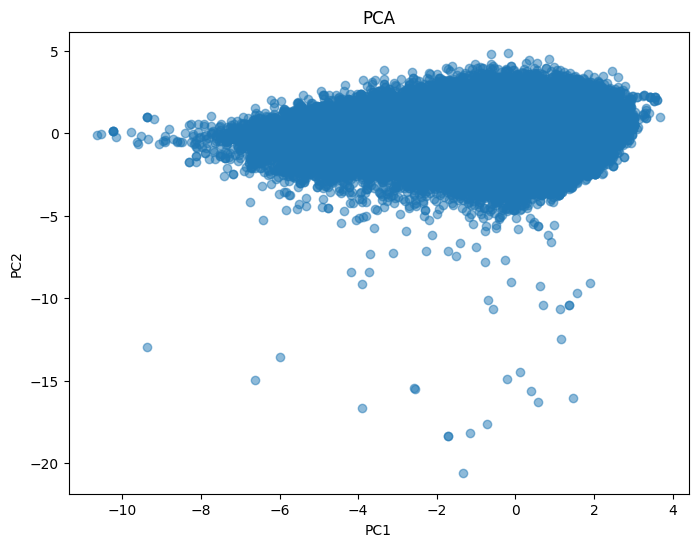

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Wyjaśniona wariancja przez komponenty:", pca.explained_variance_ratio_)

print("Wartosci wlasne:", pca.explained_variance_ )


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()



[[ 7.27052789e-01  9.32329073e-01]
 [-3.26737987e+00  1.53505595e+00]
 [-1.41418894e+00  1.50325266e-04]
 ...
 [-1.09700732e+00  1.32323194e+00]
 [-4.73417252e-01 -3.91815145e-02]
 [-9.36329190e-01  1.21617072e+00]]
             PC1       PC2
0       0.727053  0.932329
1      -3.267380  1.535056
2      -1.414189  0.000150
3      -3.805457 -0.201439
4      -0.950461  0.431741
...          ...       ...
113995 -3.460049 -2.094830
113996 -5.004622 -1.586677
113997 -1.097007  1.323232
113998 -0.473417 -0.039182
113999 -0.936329  1.216171

[114000 rows x 2 columns]


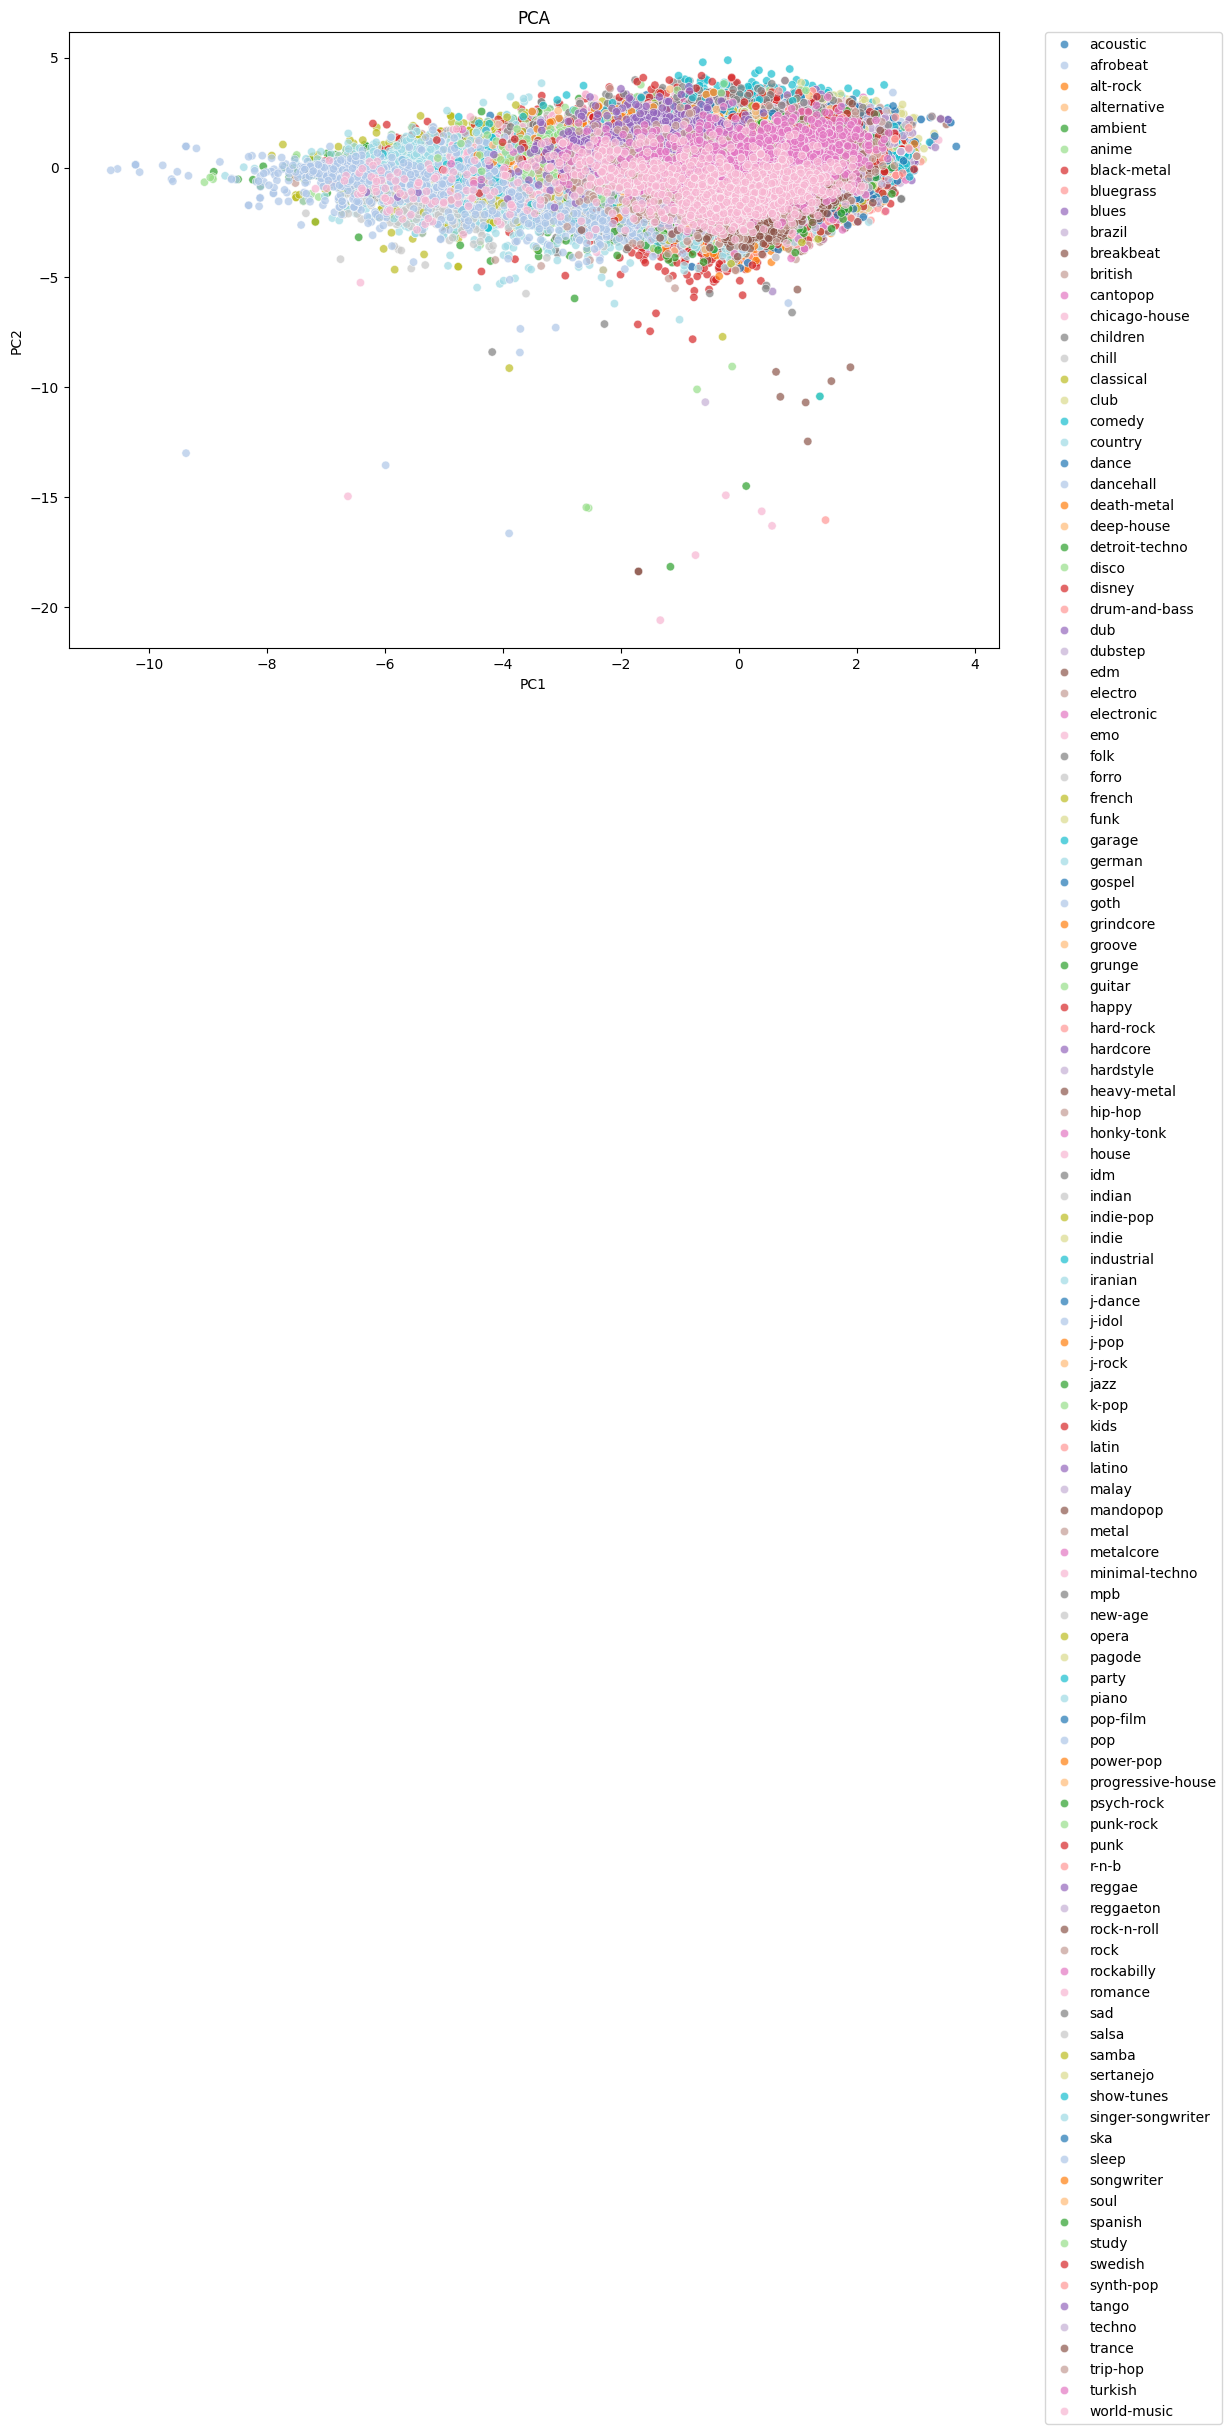

In [4]:
import seaborn as sns

print(X_pca)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print(df_pca)

df_pca['genre'] = genres

plt.figure(figsize=(12,8))
sns.scatterplot(
   data=df_pca,
   x='PC1',
   y='PC2',
   hue='genre',
   palette='tab20',
   legend='full',
   alpha=0.7
)
plt.title('PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [5]:
import numpy as np

df_loadings = pd.DataFrame(pca.components_.T, index=df.columns, columns=['PC1', 'PC2'])
print(df_loadings)

                       PC1       PC2
popularity        0.034639  0.027475
duration_ms      -0.015038 -0.406026
explicit          0.124722  0.172825
danceability      0.256060  0.451845
energy            0.489277 -0.276103
key               0.048225 -0.019790
loudness          0.498069 -0.099731
mode             -0.058785  0.093447
speechiness       0.112059  0.173484
acousticness     -0.424306  0.334547
instrumentalness -0.273114 -0.314609
liveness          0.076237 -0.100529
valence           0.284745  0.434800
tempo             0.177123 -0.248197
time_signature    0.196869  0.057414


In [6]:
print("Najważniejsze cechy dla PC1:")
print(df_loadings['PC1'].abs().sort_values(ascending=False))

print("\nNajważniejsze cechy dla PC2:")
print(df_loadings['PC2'].abs().sort_values(ascending=False))


Najważniejsze cechy dla PC1:
loudness            0.498069
energy              0.489277
acousticness        0.424306
valence             0.284745
instrumentalness    0.273114
danceability        0.256060
time_signature      0.196869
tempo               0.177123
explicit            0.124722
speechiness         0.112059
liveness            0.076237
mode                0.058785
key                 0.048225
popularity          0.034639
duration_ms         0.015038
Name: PC1, dtype: float64

Najważniejsze cechy dla PC2:
danceability        0.451845
valence             0.434800
duration_ms         0.406026
acousticness        0.334547
instrumentalness    0.314609
energy              0.276103
tempo               0.248197
speechiness         0.173484
explicit            0.172825
liveness            0.100529
loudness            0.099731
mode                0.093447
time_signature      0.057414
popularity          0.027475
key                 0.019790
Name: PC2, dtype: float64
